In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sample_c = pd.read_csv(r"customer_reviews.csv")

In [7]:
print(sample_c.head())

                        Timestamp Age  Gender Shopping Platform   \
0  2026/05/05 1:57:03 PM GMT+5:30  19    Male             Amazon   
1  2026/05/05 2:07:02 PM GMT+5:30  51    Male             Amazon   
2  2026/05/05 2:08:00 PM GMT+5:30  45  Female             Amazon   
3  2026/05/05 2:31:56 PM GMT+5:30  23    Male              Zepto   
4  2026/05/05 2:34:02 PM GMT+5:30  25    Male           Flipkart   

  Product Category  Delivery Rating  Product Quality Rating  \
0      Electronics                5                       4   
1      Electronics                4                       4   
2      Accessories                4                       5   
3              NaN                5                       5   
4         Clothing                4                       4   

   Price Satisfaction Rating  Overall Rating Would you purchase again?  \
0                          4               9                       Yes   
1                          4               5                    

In [9]:
print(sample_c.tail())

                          Timestamp Age  Gender Shopping Platform   \
26  2026/05/05 10:00:35 PM GMT+5:30  29  Female             Myntra   
27  2026/05/05 10:01:09 PM GMT+5:30  24    Male             Amazon   
28  2026/05/05 10:02:03 PM GMT+5:30  20  Female            Blinkit   
29  2026/05/05 10:03:04 PM GMT+5:30  46    Male           Flipkart   
30  2026/05/05 10:21:29 PM GMT+5:30  20    Male           Flipkart   

   Product Category  Delivery Rating  Product Quality Rating  \
26         Clothing                4                       3   
27      Electronics                4                       4   
28        Groceries                3                       4   
29         Clothing                3                       4   
30      Electronics                5                       5   

    Price Satisfaction Rating  Overall Rating Would you purchase again?  \
26                          4               8                       Yes   
27                          4               

In [10]:
sample_c.dropna(inplace=True)

In [17]:
print(sample_c.columns)

Index(['Timestamp', 'Age', 'Gender', 'Shopping Platform ', 'Product Category',
       'Delivery Rating', 'Product Quality Rating',
       'Price Satisfaction Rating', 'Overall Rating',
       'Would you purchase again?', 'Write a small review.', 'Sentiment'],
      dtype='object')


In [19]:
sample_c['Sentiment'] = sample_c['Overall Rating'].apply(
    lambda x: 'Positive' if x > 5 else 'Negative'
)

In [20]:
sample_c.columns = sample_c.columns.str.strip()

In [27]:
#Convert Text to Numerical Form
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(sample_c['Write a small review.'])

In [28]:
y = sample_c['Sentiment']

In [31]:
#Split dataset 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_pred = model.predict(X_test)

In [36]:
#Cleaning the data
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

sample_c['Cleaned_Review'] = sample_c['Write a small review.'].apply(clean_text)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(sample_c['Cleaned_Review'])

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(sample_c['Cleaned_Review'])
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=500
)

In [40]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [41]:
#Accuracy 
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.6666666666666666


In [42]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 119 stored elements and shape (30, 85)>

In [43]:
#Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [44]:
sample_c['Cluster'] = kmeans.labels_
print(sample_c[['Write a small review.', 'Cluster']])

                                Write a small review.  Cluster
0   To be honest i am purchasing so many things fr...        2
1      Good  service and timely delivery the products        2
2               Flexible to shop at anytime anywhere         0
4                                               Good         1
5                                               Good         1
6               Can get products in affordable price         2
7   I recently bought this electronic product and ...        0
8   I always prefer to buy through the amazon only...        0
9   I recently purchased Skimmed milk but the manu...        0
10  The products they provide with quality and pri...        0
11  Recently I bought a new smart watch. It was wo...        0
12               I'm not satisfied with the quality..        0
13  I purchased few vegetables some were good and ...        0
14                      They can improve the quality         0
15                                               Good  

In [48]:
#| Review       | Cluster |

 #Fast delivery     0       
 #Poor quality      1       
 #Affordable price  2     


In [49]:
#Count cluster members
print(sample_c['Cluster'].value_counts())

Cluster
0    17
1     7
2     6
Name: count, dtype: int64


In [50]:
#Customers were grouped into different categories based on review similarity. Some clusters represented delivery issues, while others represented pricing satisfaction and product quality concerns.

In [52]:
X_reg = sample_c[[
    'Delivery Rating',
    'Product Quality Rating',
    'Price Satisfaction Rating'
]]

In [55]:
print(sample_c.columns)

Index(['Timestamp', 'Age', 'Gender', 'Shopping Platform', 'Product Category',
       'Delivery Rating', 'Product Quality Rating',
       'Price Satisfaction Rating', 'Overall Rating',
       'Would you purchase again?', 'Write a small review.', 'Sentiment',
       'Cleaned_Review', 'Cluster'],
      dtype='object')


In [56]:
y_reg = sample_c['Overall Rating']

In [57]:
#Linear Regression
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_reg, y_reg)
pred = reg.predict(X_reg)

In [58]:
#mean squared error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_reg, pred)

print("MSE:", mse)

MSE: 2.111738576518759


In [59]:
#Regression result - The Linear Regression model achieved a Mean Squared Error (MSE) value of 2.11 while predicting customer satisfaction scores.

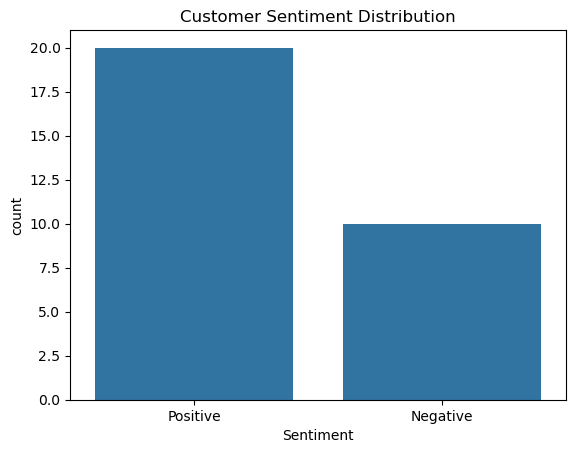

In [60]:
#Sentiment Distribution graph
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sentiment', data=sample_c)

plt.title("Customer Sentiment Distribution")

plt.show()

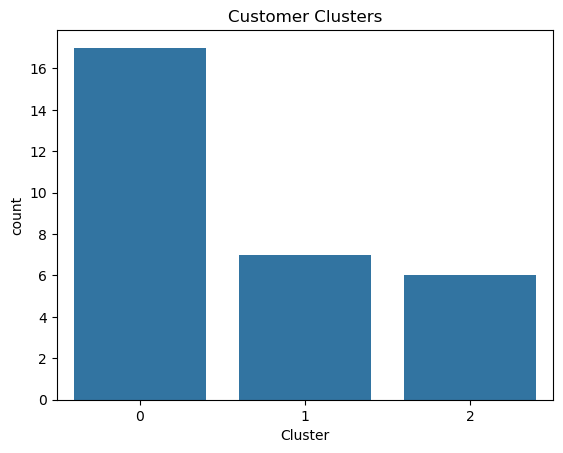

In [62]:
#Cluster Distribution Graph
sns.countplot(x='Cluster', data=sample_c)

plt.title("Customer Clusters")

plt.show()

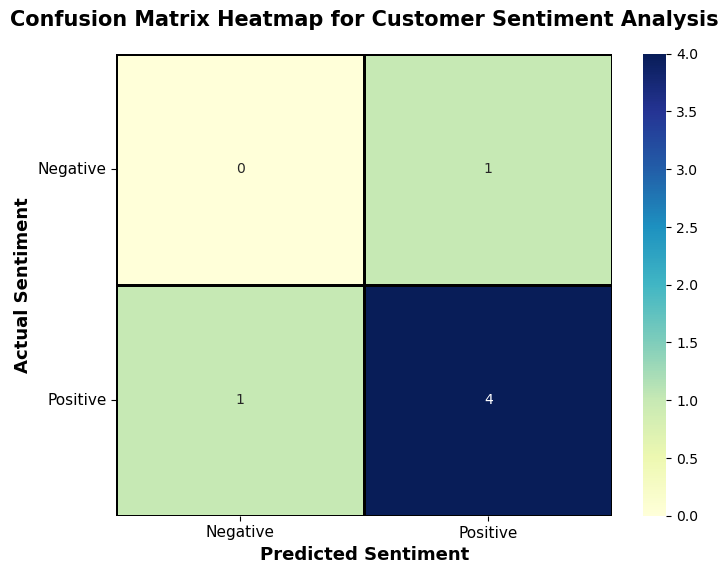

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Labels
labels = ['Negative', 'Positive']

# Create Figure
plt.figure(figsize=(8,6))

# Heatmap
sns.heatmap(
    cm,
    annot=True,                 # Show numbers inside boxes
    fmt='d',                    # Integer format
    cmap='YlGnBu',              # Color theme
    cbar=True,                  # Show color bar
    linewidths=2,               # Border thickness
    linecolor='black',
    xticklabels=labels,
    yticklabels=labels
)

# Axis Labels
plt.xlabel("Predicted Sentiment", fontsize=13, fontweight='bold')
plt.ylabel("Actual Sentiment", fontsize=13, fontweight='bold')

# Title
plt.title(
    "Confusion Matrix Heatmap for Customer Sentiment Analysis",
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Rotate labels
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

# Show Plot
plt.show()

In [75]:
#A confusion matrix heatmap was generated to visually evaluate the sentiment classification model. The heatmap clearly shows correct and incorrect predictions made by the Logistic Regression model to compare actual and predicted sentimental labels

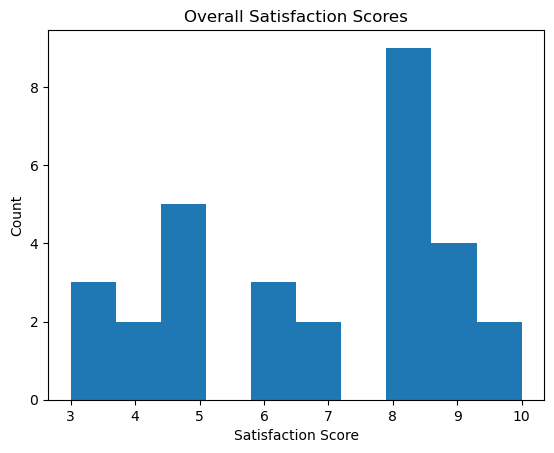

In [76]:
#Satisfaction Histogram
plt.hist(sample_c['Overall Rating'])

plt.title("Overall Satisfaction Scores")

plt.xlabel("Satisfaction Score")

plt.ylabel("Count")

plt.show()

In [77]:
#Common Review Words
from collections import Counter

text = " ".join(sample_c['Write a small review.'])

words = text.split()

common_words = Counter(words).most_common(10)

print(common_words)

[('and', 11), ('Good', 8), ('the', 6), ('I', 5), ('is', 5), ('products', 4), ('a', 4), ('in', 3), ('were', 3), ('few', 3)]


In [78]:
#Insight 1-Most customers expressed positive sentiment toward online shopping services.
#Insight 2-Late delivery and damaged products were common issues identified from customer reviews.
#Insight 3-Customers who rated product quality highly also showed higher overall satisfaction.
#Insight 4-Clustering helped group customers based on delivery concerns, pricing satisfaction, and product quality feedback.
#Insight 5-Delivery experience strongly influenced customer repurchase intention.

In [79]:
#Final Conclusion - This project successfully analyzed customer satisfaction in online shopping platforms using Data Science and Machine Learning techniques.Customer reviews were collected using Google Forms and processed using Classification, Clustering, Regression, Text Analysis

#The system generated useful business insights related to delivery performance, product quality, pricing satisfaction, and customer behavior.
